# Pilotage intelligent de la facture d'electricite d'un batiment

**Groupe 4  .  Programme d'introduction a l'intelligence artificielle (PIIA), cohorte 2  .  Academie des Mathematiques Appliquees**

Ce notebook accompagne le rapport. Il est organise dans le meme ordre que le rapport :
les donnees, le modele, la solution directe, la descente de gradient, le conditionnement,
la partie statistique, le graphe de recommandation, puis la comparaison finale.

On execute les cellules de haut en bas. On utilise seulement deux bibliotheques :
NumPy pour le calcul, et Matplotlib pour les graphiques.

In [1]:
# Nous importons les deux seules bibliotheques dont nous avons besoin.
import numpy as np
import matplotlib.pyplot as plt

# Nous fixons le hasard pour obtenir toujours les memes resultats.
np.random.seed(42)

## Section 0 : Les donnees

Le sujet ne fournit aucun fichier de mesures. Nous fabriquons donc nous-memes des donnees
qui ressemblent a la realite. Pour chaque heure, nous tirons une temperature et un nombre
d'occupants, puis nous calculons la consommation avec une formule que nous choisissons,
en ajoutant un peu de hasard.

Nous rendons la temperature liee a l'heure : il fait plus chaud l'apres-midi. Ces deux
informations se ressemblent donc un peu, ce qui nous servira plus loin (redondance et
conditionnement).

Comme nous connaissons les vrais poids de depart, nous pourrons verifier plus tard que le
modele les retrouve.

In [2]:
# Nombre d'heures observees.
n = 200

# Heure de la journee, entre 8h et 18h.
heure = np.random.uniform(8, 18, n)

# Temperature liee a l'heure : plus chaud l'apres-midi, avec un peu de hasard.
temperature = 22 + 0.9 * (heure - 8) + np.random.normal(0, 1.5, n)

# Nombre d'occupants, assez independant du reste.
occupants = np.random.uniform(0, 40, n)

# Nous rangeons les trois informations en colonnes : c'est la matrice des donnees.
X_brut = np.column_stack([heure, temperature, occupants])

# Nous mettons chaque colonne a la meme echelle (moyenne 0, ecart type 1).
# C'est important car les echelles sont tres differentes (heures, degres, personnes).
moyennes = X_brut.mean(axis=0)
ecarts = X_brut.std(axis=0)
X = (X_brut - moyennes) / ecarts

# Nous choisissons les vrais poids, puis nous calculons la consommation en kWh.
vrai_beta = np.array([4.0, 12.0, 8.0])
consommation_base = 50.0
bruit = np.random.normal(0, 2.0, n)
y_reel = consommation_base + X @ vrai_beta + bruit

# Nous gardons la consommation moyenne, puis nous centrons y pour l'entrainement.
consommation_moyenne = y_reel.mean()
y = y_reel - consommation_moyenne

# Verifions que la temperature et l'heure se ressemblent (forte correlation).
correlation = np.corrcoef(X[:, 0], X[:, 1])[0, 1]
print("Correlation entre l'heure et la temperature :", round(correlation, 3))
print("Consommation moyenne :", round(consommation_moyenne, 2), "kWh")

Correlation entre l'heure et la temperature : 0.874
Consommation moyenne : 49.89 kWh


## Section 1 : Le modele et la fonction de cout

Nous supposons que la consommation est une combinaison des informations, plus un petit
bruit. Nous cherchons les poids beta qui collent le mieux aux mesures.

Pour mesurer l'erreur, nous utilisons la fonction de cout du sujet, avec un terme de
penalite regle par lambda :

J(beta) = (1/n) somme des carres des ecarts + lambda fois la somme des carres des poids

Le gradient, calcule a la main dans le rapport, vaut :

gradient de J = (2/n) X transpose (X beta moins y) + 2 lambda beta

In [3]:
def cout(X, y, beta, lam):
    # Fonction de cout : erreur moyenne au carre + penalite sur les poids.
    n = X.shape[0]
    ecarts = X @ beta - y
    return (1/n) * np.sum(ecarts**2) + lam * np.sum(beta**2)


def gradient(X, y, beta, lam):
    # Gradient de la fonction de cout, demontre a la main dans le rapport.
    n = X.shape[0]
    ecarts = X @ beta - y
    return (2/n) * X.T @ ecarts + 2 * lam * beta

## Section 2 : La solution directe (equations normales)

Comme la fonction de cout est convexe, il existe une formule directe qui donne les meilleurs
poids d'un seul coup. En annulant le gradient, on obtient :

beta = (X transpose X + n lambda I) puissance moins un, fois X transpose y

Nous gardons la convention avec n lambda, cohérente avec le (1/n) du cout.

In [4]:
def equations_normales(X, y, lam):
    # Solution exacte des poids par la formule directe.
    n, p = X.shape
    A = X.T @ X + n * lam * np.eye(p)
    return np.linalg.solve(A, X.T @ y)   # plus stable que d'inverser la matrice


lam = 0.1
beta_exact = equations_normales(X, y, lam)
print("Poids par les equations normales :", beta_exact.round(4))

Poids par les equations normales : [5.2277 9.8716 7.2835]


## Section 3 : La descente de gradient

Nous cherchons maintenant les memes poids, mais pas a pas. Nous partons de zero, puis nous
avancons a chaque etape dans le sens oppose au gradient. Le pas est regle par alpha.

Nous nous arretons quand le gradient devient tres petit.

In [5]:
def descente_gradient(X, y, lam, alpha, max_iter=5000, tol=1e-8):
    p = X.shape[1]
    beta = np.zeros(p)                 # nous partons de poids nuls
    historique = [cout(X, y, beta, lam)]
    for i in range(max_iter):
        g = gradient(X, y, beta, lam)
        if np.linalg.norm(g) < tol:    # critere d'arret
            break
        beta = beta - alpha * g        # mise a jour dans le sens oppose au gradient
        historique.append(cout(X, y, beta, lam))
    return beta, np.array(historique)


beta_dg, historique = descente_gradient(X, y, lam, alpha=0.1)
print("Poids par la descente de gradient :", beta_dg.round(4))
print("Poids par les equations normales  :", beta_exact.round(4))
print("Ecart entre les deux methodes     :", np.linalg.norm(beta_dg - beta_exact))

Poids par la descente de gradient : [5.2277 9.8716 7.2835]
Poids par les equations normales  : [5.2277 9.8716 7.2835]
Ecart entre les deux methodes     : 2.1521637213292785e-08


On voit que les deux methodes donnent le meme resultat. C'est notre premiere validation :
la theorie et le calcul sont d'accord.

Regardons la courbe du cout au fil des etapes.

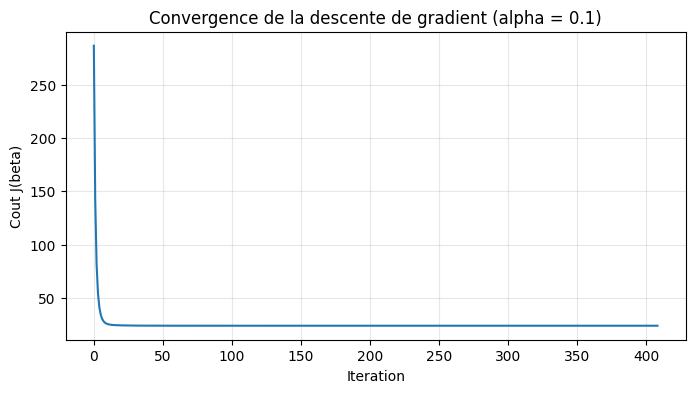

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(historique)
plt.xlabel("Iteration")
plt.ylabel("Cout J(beta)")
plt.title("Convergence de la descente de gradient (alpha = 0.1)")
plt.grid(True, alpha=0.3)
plt.show()

### Sensibilite au pas d'apprentissage

Le choix du pas alpha est important. S'il est trop grand, l'algorithme rebondit et diverge.
Testons plusieurs valeurs.

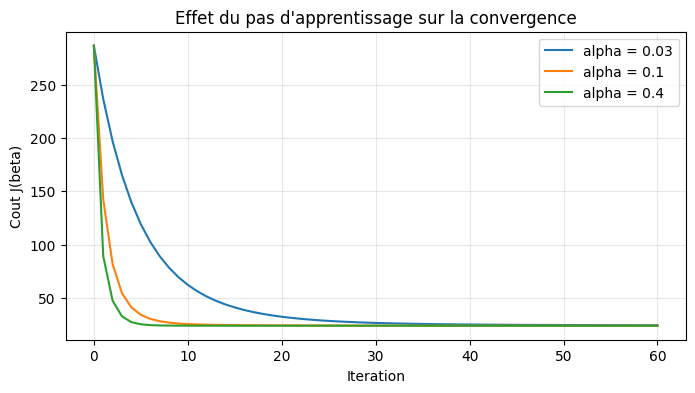

Cout final avec alpha = 1.0 : 1.0012445779421874e+50
L'algorithme diverge : le cout explose au lieu de diminuer.


In [7]:
# Nous comparons trois pas qui restent stables.
plt.figure(figsize=(8, 4))
for alpha in [0.03, 0.1, 0.4]:
    _, hist = descente_gradient(X, y, lam, alpha=alpha, max_iter=60)
    plt.plot(hist, label=f"alpha = {alpha}")
plt.xlabel("Iteration")
plt.ylabel("Cout J(beta)")
plt.title("Effet du pas d'apprentissage sur la convergence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Avec un pas trop grand, l'algorithme diverge.
_, hist_diverge = descente_gradient(X, y, lam, alpha=1.0, max_iter=50)
print("Cout final avec alpha = 1.0 :", hist_diverge[-1])
print("L'algorithme diverge : le cout explose au lieu de diminuer.")

## Section 4 : Le conditionnement et l'effet de la penalite

Quand les variables se ressemblent (ici l'heure et la temperature), la surface d'erreur
devient un long couloir etroit, un ravin. La descente de gradient y avance lentement.

Le nombre de conditionnement, note kappa, mesure ce probleme. C'est le rapport entre la plus
grande et la plus petite valeur propre de la matrice (1/n) X transpose X. Proche de un, tout
va bien. Tres grand, c'est un ravin.

La penalite lambda ajoute la meme valeur a chaque valeur propre, ce qui rapproche kappa de
un. C'est demontre a la main dans le rapport.

Valeurs propres : [1.9019 0.9734 0.1247]
Conditionnement sans penalite : 15.25


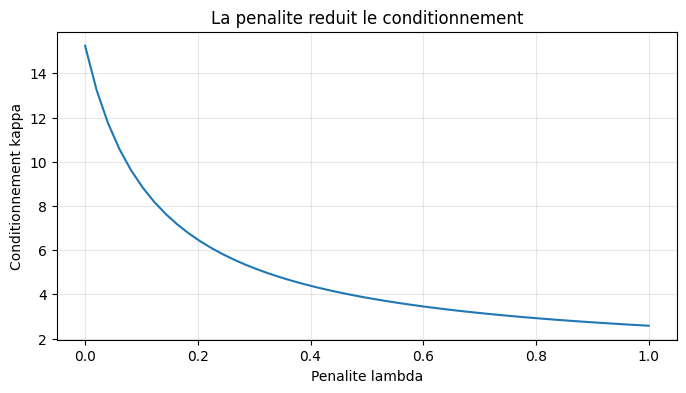

Avec lambda = 0.1, kappa passe de 15.25 a 8.91


In [8]:
# Valeurs propres de la matrice (1/n) X transpose X.
A = (1/n) * X.T @ X
valeurs_propres = np.sort(np.linalg.eigvalsh(A))[::-1]
print("Valeurs propres :", valeurs_propres.round(4))

kappa_sans = valeurs_propres[0] / valeurs_propres[-1]
print("Conditionnement sans penalite :", round(kappa_sans, 2))

# Conditionnement quand on ajoute la penalite lambda.
liste_lambda = np.linspace(0, 1, 50)
liste_kappa = (valeurs_propres[0] + liste_lambda) / (valeurs_propres[-1] + liste_lambda)

plt.figure(figsize=(8, 4))
plt.plot(liste_lambda, liste_kappa)
plt.xlabel("Penalite lambda")
plt.ylabel("Conditionnement kappa")
plt.title("La penalite reduit le conditionnement")
plt.grid(True, alpha=0.3)
plt.show()

print("Avec lambda = 0.1, kappa passe de",
      round(kappa_sans, 2), "a",
      round((valeurs_propres[0] + 0.1) / (valeurs_propres[-1] + 0.1), 2))

## Section 5 : Les intervalles de confiance

Trouver des poids ne suffit pas. Nous voulons savoir si chaque poids compte vraiment, ou
s'il pourrait etre nul. Pour cela, nous calculons un intervalle de confiance autour de
chaque poids.

Nous utilisons la solution des moindres carres ordinaires (sans penalite). Nous estimons le
bruit a partir des residus, puis nous en deduisons l'incertitude sur chaque poids. La
methode vient de la statistique classique de la regression (voir la reference dans le
rapport).

In [9]:
# Poids sans penalite (moindres carres ordinaires).
beta_ols = np.linalg.solve(X.T @ X, X.T @ y)

# Les residus sont les ecarts entre les predictions et les mesures.
residus = y - X @ beta_ols
p = X.shape[1]

# Nous estimons la variance du bruit.
variance_bruit = np.sum(residus**2) / (n - p)

# L'incertitude sur les poids vient de cette variance.
matrice_covariance = variance_bruit * np.linalg.inv(X.T @ X)
erreurs_standard = np.sqrt(np.diag(matrice_covariance))

noms = ["heure", "temperature", "occupants"]
print("Intervalles de confiance a 95 pour cent :")
for j in range(p):
    bas = beta_ols[j] - 1.96 * erreurs_standard[j]
    haut = beta_ols[j] + 1.96 * erreurs_standard[j]
    significatif = "significatif" if (bas > 0 or haut < 0) else "non significatif"
    print(f"  {noms[j]:12s} : [{bas:6.3f} ; {haut:6.3f}]  {significatif}")

Intervalles de confiance a 95 pour cent :
  heure        : [ 3.360 ;  4.521]  significatif
  temperature  : [11.476 ; 12.633]  significatif
  occupants    : [ 7.763 ;  8.329]  significatif


Les trois intervalles ne contiennent pas zero : les trois variables comptent vraiment.
De plus, les poids trouves sont tres proches des vrais poids de depart. C'est une deuxieme
validation qui confronte la theorie et l'experience.

## Section 6 : Le graphe et la recommandation

Nous transformons enfin la prediction en conseil concret. Nous decoupons la journee en
quelques heures. A chaque heure, le batiment peut etre dans un etat, par exemple un mode
normal ou un mode economie. Chaque etat a une consommation prevue par notre modele.

On ne peut avancer que dans le temps : un etat du matin mene vers un etat plus tard, jamais
en arriere. Le graphe est donc oriente et sans cycle. Nous cherchons la suite d'etats qui
donne la plus faible consommation sur la journee.

Pour le confort, le mode economie est interdit aux heures les plus chaudes (12h et 14h).

In [10]:
def predire(h, t, occ, beta):
    # Consommation prevue par le modele pour un etat donne (en kWh).
    x = (np.array([h, t, occ]) - moyennes) / ecarts
    return consommation_moyenne + x @ beta


def etats_de_l_heure(h):
    # Les etats possibles a une heure donnee.
    temp_prevue = 22 + 0.9 * (h - 8)
    etats = [("normal", temp_prevue, 35)]
    if h not in (12, 14):                       # confort : pas d'economie au pic de chaleur
        etats.append(("economie", temp_prevue - 2, 20))
    return etats


heures_jour = [8, 10, 12, 14, 16, 18]
beta_modele = beta_exact                        # nous utilisons le modele regularise

# Nous construisons les couches du graphe : une couche par heure.
couches = []
for h in heures_jour:
    couche = []
    for nom, t, occ in etats_de_l_heure(h):
        couche.append((nom, predire(h, t, occ, beta_modele)))
    couches.append(couche)

Nous cherchons le meilleur chemin par programmation dynamique : pour chaque etat, nous
gardons le plus petit cout cumule pour y arriver. C'est simple car le graphe est sans
cycle.

In [11]:
INFINI = float("inf")
nb_couches = len(couches)
cout_min = [[INFINI] * len(c) for c in couches]
choix = [[None] * len(c) for c in couches]

# Premiere heure : le cout est juste la consommation de l'etat.
for j, (nom, conso) in enumerate(couches[0]):
    cout_min[0][j] = conso

# Heures suivantes : on ajoute la consommation au meilleur chemin precedent.
for i in range(1, nb_couches):
    for j, (nom, conso) in enumerate(couches[i]):
        for k in range(len(couches[i-1])):
            candidat = cout_min[i-1][k] + conso
            if candidat < cout_min[i][j]:
                cout_min[i][j] = candidat
                choix[i][j] = k

# Nous remontons le meilleur chemin.
fin = int(np.argmin(cout_min[-1]))
chemin = [fin]
for i in range(nb_couches - 1, 0, -1):
    chemin.append(choix[i][chemin[-1]])
chemin = chemin[::-1]

total_optimal = min(cout_min[-1])
print("Recommandation heure par heure :")
for i, h in enumerate(heures_jour):
    nom, conso = couches[i][chemin[i]]
    print(f"  {h:2d}h : mode {nom:9s} ({conso:.1f} kWh)")
print("Consommation cumulee optimale :", round(total_optimal, 1), "kWh")

Recommandation heure par heure :
   8h : mode economie  (20.1 kWh)
  10h : mode economie  (29.6 kWh)
  12h : mode normal    (54.8 kWh)
  14h : mode normal    (64.3 kWh)
  16h : mode economie  (58.1 kWh)
  18h : mode economie  (67.6 kWh)
Consommation cumulee optimale : 294.4 kWh


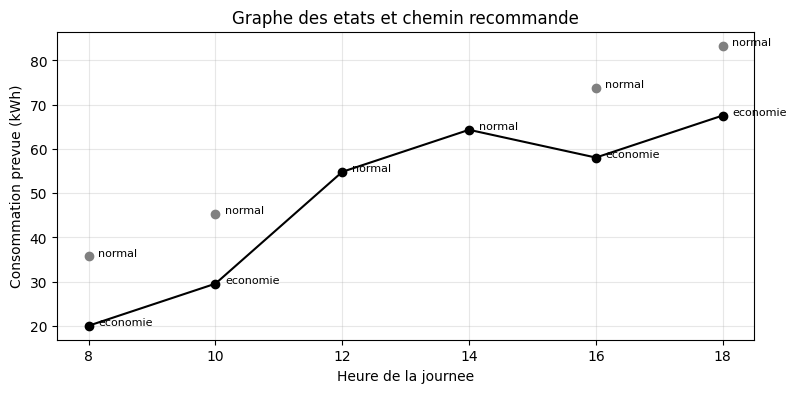

In [12]:
# Un petit dessin du graphe et du chemin choisi.
plt.figure(figsize=(9, 4))
for i, h in enumerate(heures_jour):
    for j, (nom, conso) in enumerate(couches[i]):
        couleur = "black" if j == chemin[i] else "gray"
        plt.scatter(h, conso, color=couleur, zorder=3)
        plt.text(h + 0.15, conso, nom, fontsize=8)
# le chemin choisi
xs = [heures_jour[i] for i in range(nb_couches)]
ys = [couches[i][chemin[i]][1] for i in range(nb_couches)]
plt.plot(xs, ys, color="black", linewidth=1.5, zorder=2)
plt.xlabel("Heure de la journee")
plt.ylabel("Consommation prevue (kWh)")
plt.title("Graphe des etats et chemin recommande")
plt.grid(True, alpha=0.3)
plt.show()

## Section 7 : Comparaison avec une methode simple

Pour finir, nous comparons notre recommandation a une strategie de reference : garder le
mode normal toute la journee, sans optimisation.

In [13]:
total_normal = sum(predire(h, *etats_de_l_heure(h)[0][1:], beta_modele) for h in heures_jour)
economie = total_normal - total_optimal

print("Strategie normale (sans optimisation) :", round(total_normal, 1), "kWh")
print("Strategie recommandee (notre graphe)  :", round(total_optimal, 1), "kWh")
print("Economie realisee                     :", round(economie, 1), "kWh")
print("Soit une baisse de", round(100 * economie / total_normal, 1), "pour cent.")

Strategie normale (sans optimisation) : 357.5 kWh
Strategie recommandee (notre graphe)  : 294.4 kWh
Economie realisee                     : 63.1 kWh
Soit une baisse de 17.6 pour cent.


Notre outil ne se contente pas de predire : il propose un vrai plan d'action qui reduit la
consommation, tout en gardant le confort aux heures chaudes.